In [10]:
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z0 = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e
eps = 1
alpha = 1/137.06
m_dm = 2.873e-25
m_ion = c.m 
Z_charge = c.Z

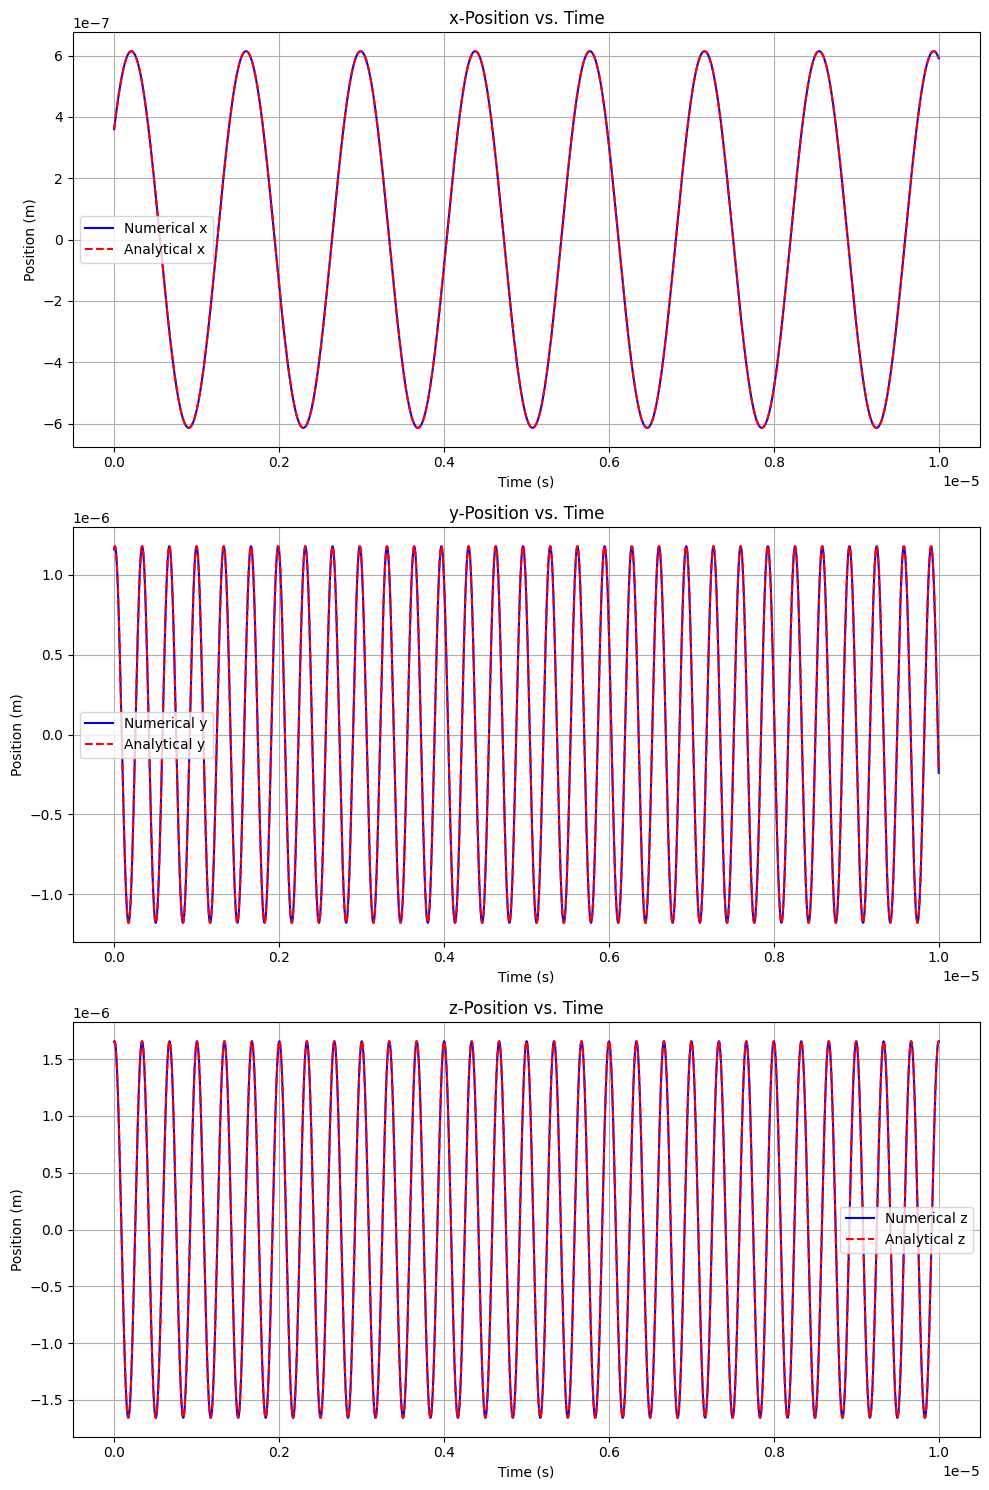

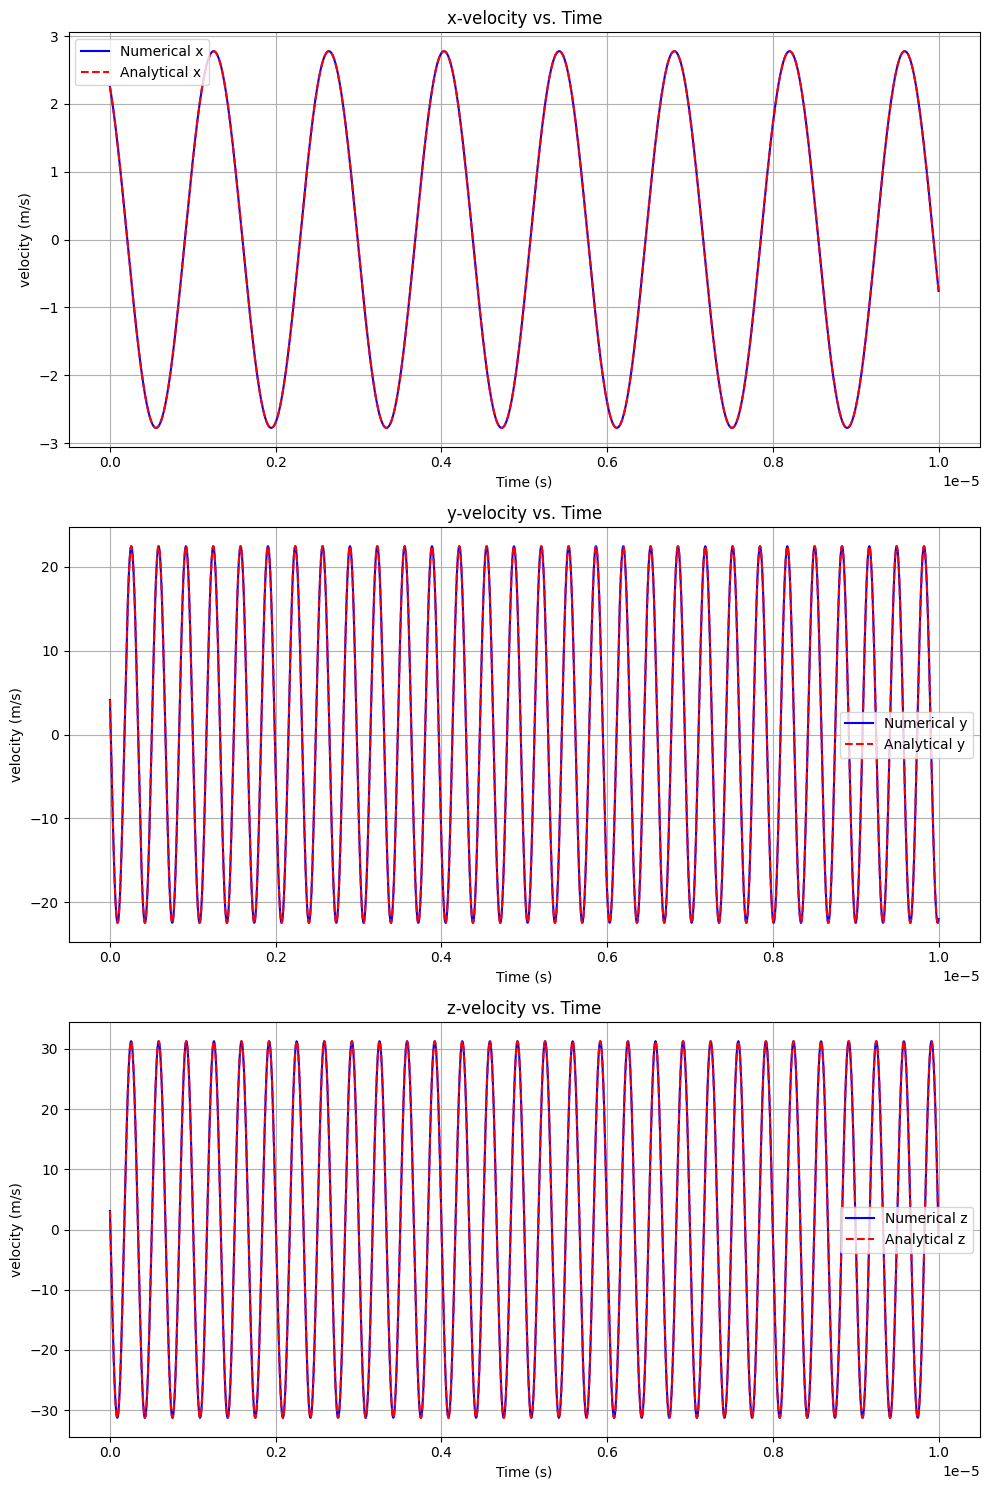

Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1e-05


In [11]:
## 1a. Simulate simple harmonic motion of an ion in an ion trap
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega = 2*pi*np.array([freq_x,freq_y,freq_z])
omega_original = omega

# Random initial condition x0<2um; v0<5m/s
x1_0 = np.random.randint(0,200)/100*um
x2_0 = np.random.randint(0,200)/100*um
x3_0 = np.random.randint(0,200)/100*um
v1_0 = np.random.randint(0,500)/100
v2_0 = np.random.randint(0,500)/100
v3_0 = np.random.randint(0,500)/100
x0 = [x1_0,x2_0,x3_0] # initial position
v0 = [v1_0,v2_0,v3_0] # initial velocity
U0 = np.array([x0,v0])
U0 = U0.flatten()

# Numerical solution to -(omega^2)x = x''
def fun(t,U):
    x1,x2,x3,v1,v2,v3 = U
    x = U[0:3]
    v = U[3:6]
    dxdt = v
    dvdt = -1*omega**2*x
    return np.concatenate([dxdt,dvdt])

t_eval = np.linspace(0,1e-5,2000)
t_span = (0,1e-5)
sol = solve_ivp(fun,t_span,U0,method='RK45',t_eval=t_eval,dense_output=True,
            rtol=1e-15,
            atol=1e-15)
x1_sol = sol.y[0]
x2_sol = sol.y[1]
x3_sol = sol.y[2]
v1_sol = sol.y[3]
v2_sol = sol.y[4]
v3_sol = sol.y[5]
"""
print(f"x-position: \n {x1_sol}")
print(f"y-position: \n {x2_sol}")
print(f"z-position: \n {x3_sol}")
print(f"x-velocity: \n {v1_sol}")
print(f"y-velocity: \n {v2_sol}")
print(f"z-velocity: \n {v3_sol}")
"""

# Analytical solution
def x_t(omega,x0,v0,t):
    return x0*np.cos(omega*t)+(v0/omega)*np.sin(omega*t)
def v_t(omega,x0,v0,t):
    return -1*omega*x0*np.sin(omega*t)+v0*np.cos(omega*t)
x1_sol_analytic = []
x2_sol_analytic = []
x3_sol_analytic = []
v1_sol_analytic = []
v2_sol_analytic = []
v3_sol_analytic = []
for t in t_eval:
    x1_sol_analytic.append(x_t(omega[0],x1_0,v1_0,t))
    x2_sol_analytic.append(x_t(omega[1],x2_0,v2_0,t))
    x3_sol_analytic.append(x_t(omega[2],x3_0,v3_0,t))
    v1_sol_analytic.append(v_t(omega[0],x1_0,v1_0,t))
    v2_sol_analytic.append(v_t(omega[1],x2_0,v2_0,t))
    v3_sol_analytic.append(v_t(omega[2],x3_0,v3_0,t))
"""
print(f"x-position analytic: \n {x1_sol_analytic}")
print(f"y-position analytic: \n {x2_sol_analytic}")
print(f"z-position analytic: \n {x3_sol_analytic}")
print(f"x-velocity analytic: \n {v1_sol_analytic}")
print(f"y-velocity analytic: \n {v2_sol_analytic}")
print(f"z-velocity analytic: \n {v3_sol_analytic}")
"""

fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # 3 rows, 1 column for x, y, and z

# Plot x-position
axes[0].plot(sol.t, x1_sol, 'b-', label='Numerical x')
axes[0].plot(t_eval, x1_sol_analytic, 'r--', label='Analytical x')
axes[0].set_title('x-Position vs. Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].legend()
axes[0].grid(True)

# Plot y-position
axes[1].plot(sol.t, x2_sol, 'b-', label='Numerical y')
axes[1].plot(t_eval, x2_sol_analytic, 'r--', label='Analytical y')
axes[1].set_title('y-Position vs. Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Position (m)')
axes[1].legend()
axes[1].grid(True)

# Plot z-position
axes[2].plot(sol.t, x3_sol, 'b-', label='Numerical z')
axes[2].plot(t_eval, x3_sol_analytic, 'r--', label='Analytical z')
axes[2].set_title('z-Position vs. Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Position (m)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # 3 rows, 1 column for x, y, and z

# Plot x-velocity
axes[0].plot(sol.t, v1_sol, 'b-', label='Numerical x')
axes[0].plot(t_eval, v1_sol_analytic, 'r--', label='Analytical x')
axes[0].set_title('x-velocity vs. Time')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('velocity (m/s)')
axes[0].legend()
axes[0].grid(True)

# Plot y-velocity
axes[1].plot(sol.t, v2_sol, 'b-', label='Numerical y')
axes[1].plot(t_eval, v2_sol_analytic, 'r--', label='Analytical y')
axes[1].set_title('y-velocity vs. Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('velocity (m/s)')
axes[1].legend()
axes[1].grid(True)

# Plot z-velocity
axes[2].plot(sol.t, v3_sol, 'b-', label='Numerical z')
axes[2].plot(t_eval, v3_sol_analytic, 'r--', label='Analytical z')
axes[2].set_title('z-velocity vs. Time')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('velocity (m/s)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

## Check solver
print("Success?", sol.success)
print("Message:", sol.message)
print("Final time:", sol.t[-1])


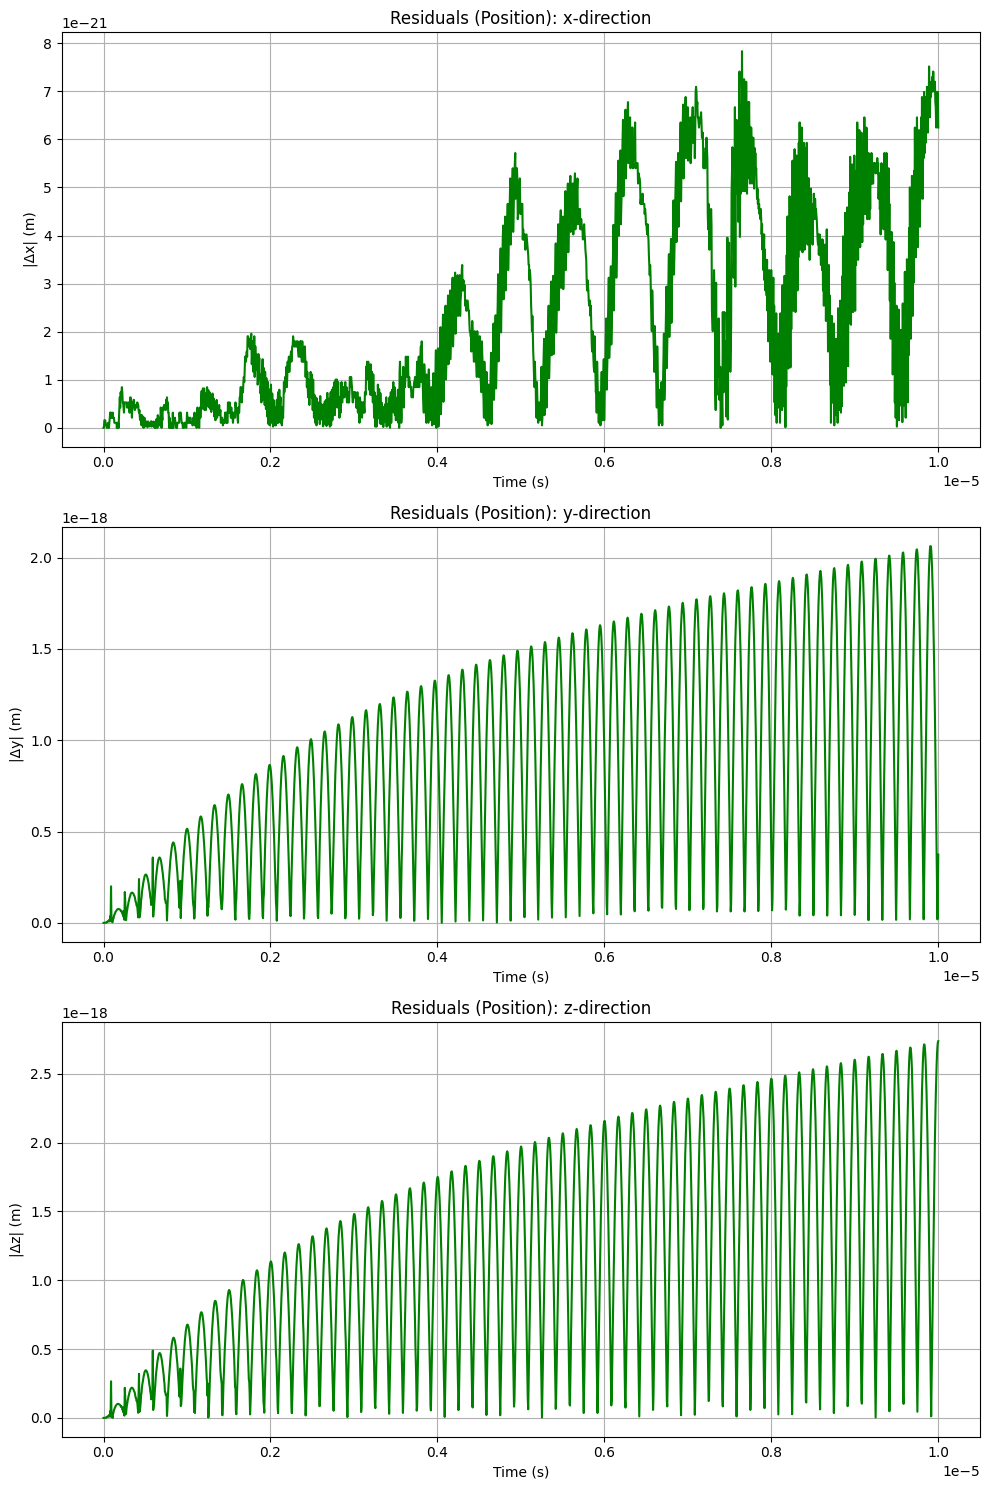

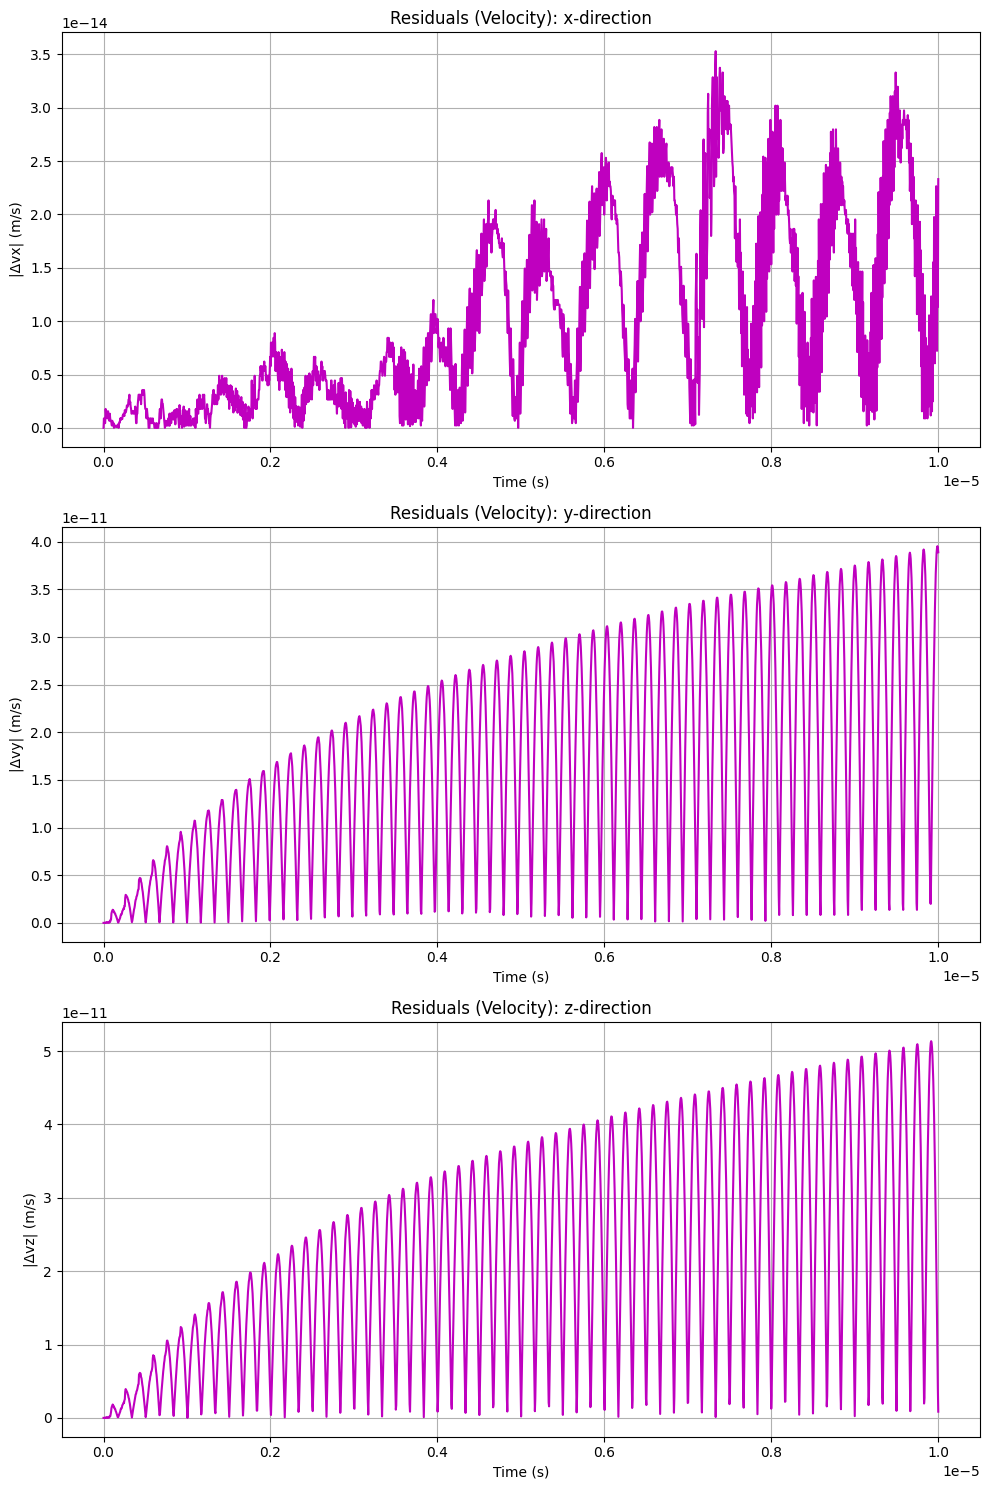

In [12]:
# --- Position residuals (absolute difference) ---
res_x_pos = np.abs(x1_sol - np.array(x1_sol_analytic))
res_y_pos = np.abs(x2_sol - np.array(x2_sol_analytic))
res_z_pos = np.abs(x3_sol - np.array(x3_sol_analytic))

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

axes[0].plot(sol.t, res_x_pos, 'g-')
axes[0].set_title('Residuals (Position): x-direction')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('|Δx| (m)')
axes[0].grid(True)

axes[1].plot(sol.t, res_y_pos, 'g-')
axes[1].set_title('Residuals (Position): y-direction')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('|Δy| (m)')
axes[1].grid(True)

axes[2].plot(sol.t, res_z_pos, 'g-')
axes[2].set_title('Residuals (Position): z-direction')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('|Δz| (m)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# --- Velocity residuals (absolute difference) ---
res_x_vel = np.abs(v1_sol - np.array(v1_sol_analytic))
res_y_vel = np.abs(v2_sol - np.array(v2_sol_analytic))
res_z_vel = np.abs(v3_sol - np.array(v3_sol_analytic))

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

axes[0].plot(sol.t, res_x_vel, 'm-')
axes[0].set_title('Residuals (Velocity): x-direction')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('|Δvx| (m/s)')
axes[0].grid(True)

axes[1].plot(sol.t, res_y_vel, 'm-')
axes[1].set_title('Residuals (Velocity): y-direction')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('|Δvy| (m/s)')
axes[1].grid(True)

axes[2].plot(sol.t, res_z_vel, 'm-')
axes[2].set_title('Residuals (Velocity): z-direction')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('|Δvz| (m/s)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

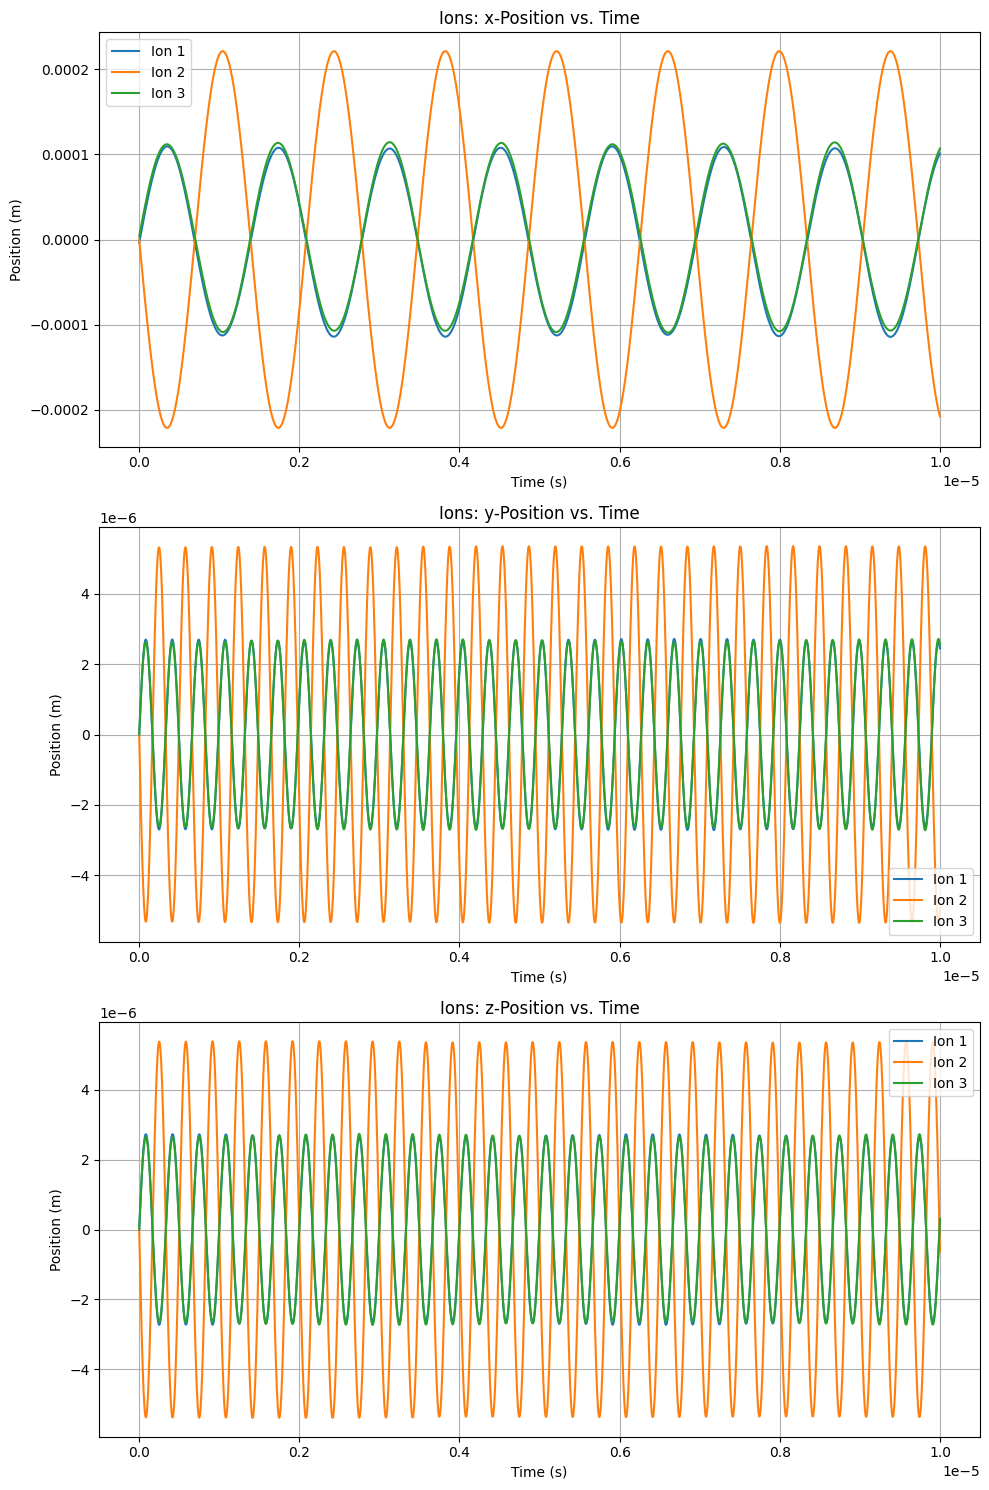

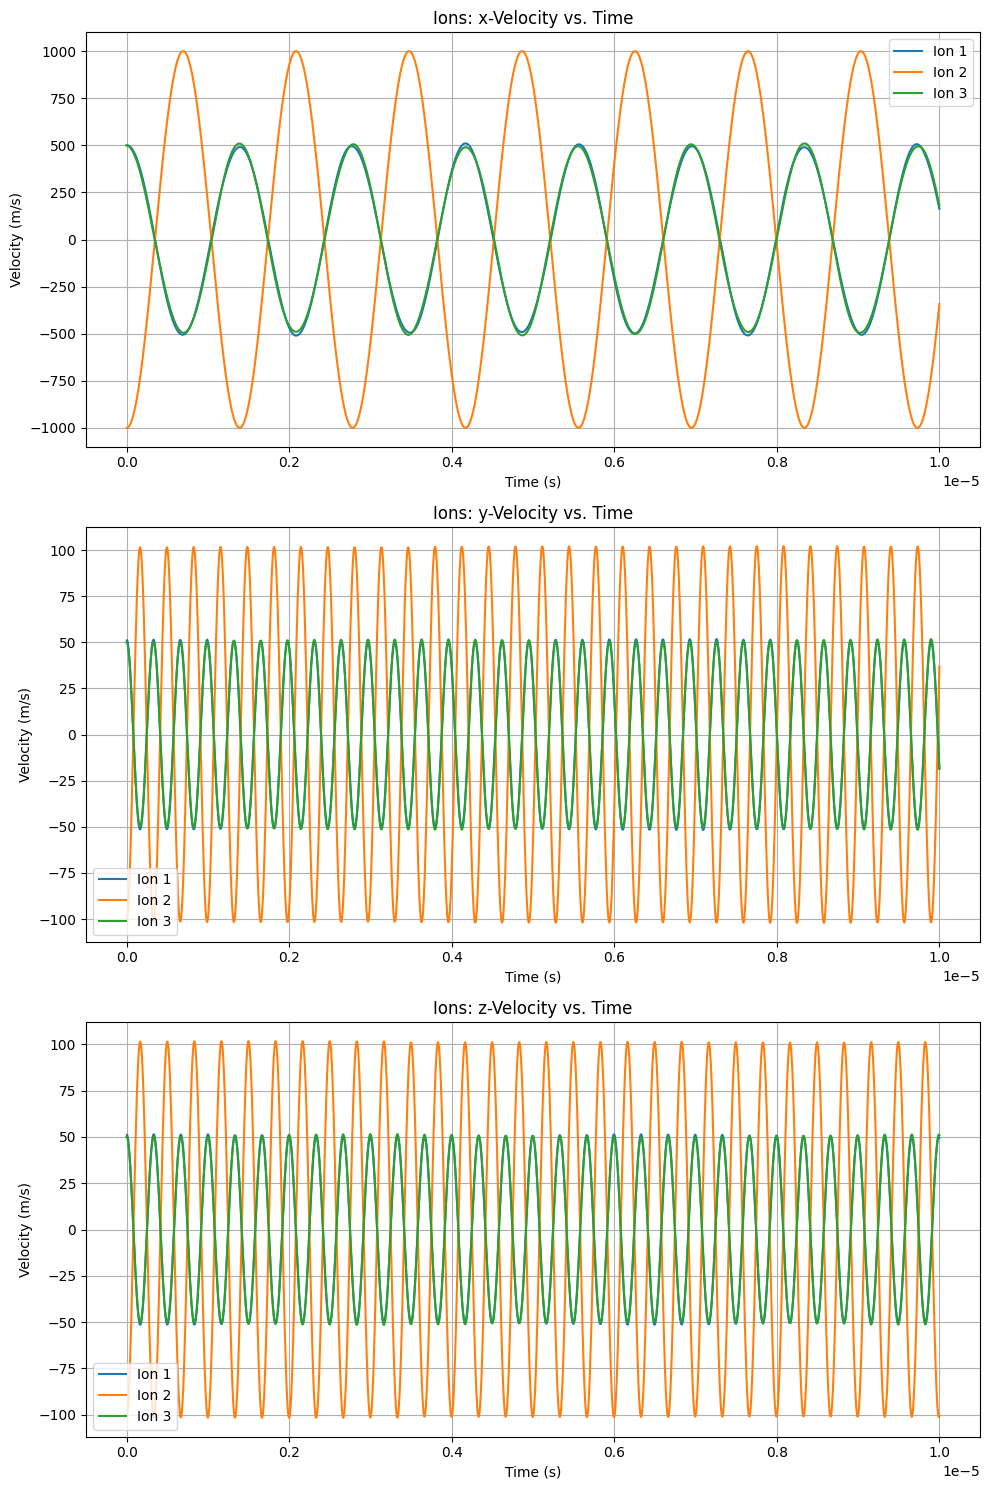

Estimated eigenfrequencies:
x-direction: 719424.5105052827
y-direction: 3030901.25790172
z-direction: 3001847.411225935
Success? True
Message: The solver successfully reached the end of the integration interval.
Final time: 1e-05


In [15]:
## 1b. Check normal modes of ion chain: apply a kick to an ion and simulate the motions for all three ions 
# Initial condition- for ion: rest and equilibrium
d_chain = 3.7e-6  # 3.7 µm separation
x0_ions = np.array([
    [-d_chain, 0, 0],
    [0, 0, 0],
    [d_chain, 0, 0]
])
v0_ions = np.array([
    [5e2, 50, 50], 
    [-10e2, -100, -100], 
    [5e2, 50, 50] 
])  # 5m/s speed for one ion
U0 = np.array([x0_ions,v0_ions])
U0 = U0.flatten()

# ODE system
def fun2(t,U):
    n_ions = 3
    x_ions = U[0:3*n_ions].reshape((n_ions,3))
    v_ions = U[3*n_ions:3*n_ions+3*n_ions].reshape((n_ions,3))
   
    # Derivatives
    dx_ionsdt = v_ions
    dv_ionsdt = np.zeros_like(x_ions)

    # Each ion: Coulomb with other ions
    for i in range(n_ions):
        for j in range(n_ions):
            if i != j:
                delta_ij = x_ions[i] - x_ions[j]
                dv_ionsdt[i] += K*e**2*delta_ij/(m_ion*np.linalg.norm(delta_ij)**3)

    # Each ion: Restoring force from harmonic trap potential
    for i in range(n_ions):
        dv_ionsdt[i] += -1*omega**2*x_ions[i]

    return np.concatenate([
        dx_ionsdt.flatten(),
        dv_ionsdt.flatten()
    ])

# Solve system
t_eval = np.linspace(0,1e-5,2000)
t_span = (0,1e-5)
sol = solve_ivp(
    fun2, t_span, U0, method='DOP853',
    t_eval=t_eval, dense_output=True,
    rtol=1e-11, atol=1e-11
)

# Extract solutions
n_ions = 3
x_ions_sol = sol.y[0:3*n_ions].reshape((n_ions,3,-1))
v_ions_sol = sol.y[3*n_ions:3*n_ions+3*n_ions].reshape((n_ions,3,-1))

## Plots for ions
fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # x, y, z positions
for i in range(n_ions):
    axes[0].plot(sol.t, x_ions_sol[i,0], label=f'Ion {i+1}')
    axes[1].plot(sol.t, x_ions_sol[i,1], label=f'Ion {i+1}')
    axes[2].plot(sol.t, x_ions_sol[i,2], label=f'Ion {i+1}')

axes[0].set_title('Ions: x-Position vs. Time')
axes[1].set_title('Ions: y-Position vs. Time')
axes[2].set_title('Ions: z-Position vs. Time')
for ax in axes:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Position (m)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(10, 15)) # x, y, z velocities
for i in range(n_ions):
    axes[0].plot(sol.t, v_ions_sol[i,0], label=f'Ion {i+1}')
    axes[1].plot(sol.t, v_ions_sol[i,1], label=f'Ion {i+1}')
    axes[2].plot(sol.t, v_ions_sol[i,2], label=f'Ion {i+1}')

axes[0].set_title('Ions: x-Velocity vs. Time')
axes[1].set_title('Ions: y-Velocity vs. Time')
axes[2].set_title('Ions: z-Velocity vs. Time')
for ax in axes:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Velocity (m/s)')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

## Estimate frequency
def fit_cosine(t, x, A_guess=None, omega_guess=None, phi_guess=0.0):
    """
    Fit x(t) = A * cos(omega * t + phi)
    Returns A, omega, phi
    """

    # Model
    def model(t, A, omega, phi):
        return A * np.cos(omega * t + phi)

    # Initial guesses if not given
    if A_guess is None:
        A_guess = (np.max(x) - np.min(x)) / 2

    if omega_guess is None:
        # crude guess based on zero crossing (FFT-free)
        signs = np.sign(x)
        crossings = np.where(np.diff(signs) != 0)[0]
        if len(crossings) >= 2:
            T_est = 2 * np.median(np.diff(t[crossings]))
            omega_guess = 2 * np.pi / T_est
        else:
            # fallback
            omega_guess = 2 * np.pi / (t[-1] - t[0])

    p0 = [A_guess, omega_guess, phi_guess]

    # Fit
    params, _ = curve_fit(model, t, x, p0=p0, maxfev=20000)

    A_fit, omega_fit, phi_fit = params
    return A_fit, omega_fit, phi_fit

dt = 1e-5/2000
x_freq_est = fit_cosine(t_eval,x_ions_sol[1,0],1)[1] # x-direction
y_freq_est = fit_cosine(t_eval,x_ions_sol[1,1],1)[1] # y-direction
z_freq_est = fit_cosine(t_eval,x_ions_sol[1,2],1)[1] # z-direction
print("Estimated eigenfrequencies:")
print(f"x-direction: {x_freq_est/(2*np.pi)}")
print(f"y-direction: {y_freq_est/(2*np.pi)}")
print(f"z-direction: {z_freq_est/(2*np.pi)}")

## Check solver
print("Success?", sol.success)
print("Message:", sol.message)
print("Final time:", sol.t[-1])